In [13]:
from pymongo import MongoClient
from bson import ObjectId
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
import torch.nn.functional as F
from Data_Preprocessing import Data_Preprocessing
import pandas as pd
import numpy as np

dp = Data_Preprocessing()

In [14]:
bitcoin_tag_id = "65118dfb8cc92b1a20969084"
investing_tag_id = "65108e38c1df798eb02becb3"

client = MongoClient('mongodb://localhost:27017/')
db = client['nlp-based-sentiment-analysis']
tweets = db['tweets'].find({"keyword": ObjectId(investing_tag_id)}) #investing

transformations = ["TEXT_TO_LOWER", "REMOVE_URLS", "REMOVE_USERNAMES", "REMOVE_PUNCTUATION_WITH_EXCLUDE", "REPLACE_WITH_BTC", "REPLACE_WITH_NVDA", "REPLACE_WITH_GOOGL", "REPLACE_WITH_AMZN", "REPLACE_WITH_AAPL", "REPLACE_WITH_TSLA", "REPLACE_WITH_MSFT", "REPLACE_WITH_SPX"]

In [15]:
def get_sentiment(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True, max_length=128)
    outputs = model(**inputs)
    probs = F.softmax(outputs.logits, dim=-1).detach().cpu().numpy()[0]
    return {"bearish": probs[0], "neutral": probs[1], "bullish": probs[2]}

In [ ]:
model_name = "ProsusAI/finbert" #"ElKulako/cryptobert" #"FacebookAI/roberta-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)

C:\Users\micha\anaconda32\lib\site-packages\huggingface_hub\file_download.py:896: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


In [17]:
df = pd.DataFrame(list(tweets))
df['day'] = pd.to_datetime(df['date']).dt.date
grouped = df.groupby('day').apply(lambda x: x.to_dict(orient='records'))

In [18]:
tweets_classified_daily = []

for group in grouped:
    day_scores = [get_sentiment(dp.apply_transformations(tweet['content'], transformations)) for tweet in group]
    
    # Convert to DataFrame for easy aggregation
    df_scores = pd.DataFrame(day_scores)
    
    tweets_classified_daily.append({
        "index": pd.to_datetime(group[0]["day"]),  # assuming all tweets in group have same day
        "bearish_mean": df_scores["bearish"].mean(),
        "bearish_min": df_scores["bearish"].min(),
        "bearish_max": df_scores["bearish"].max(),
        "bearish_std": df_scores["bearish"].std(),
        "neutral_mean": df_scores["neutral"].mean(),
        "neutral_min": df_scores["neutral"].min(),
        "neutral_max": df_scores["neutral"].max(),
        "neutral_std": df_scores["neutral"].std(),
        "bullish_mean": df_scores["bullish"].mean(),
        "bullish_min": df_scores["bullish"].min(),
        "bullish_max": df_scores["bullish"].max(),
        "bullish_std": df_scores["bullish"].std()
    })

In [19]:
pd.DataFrame(tweets_classified_daily).to_csv("Datasets/investing_classified_sentiments")

<Axes: >

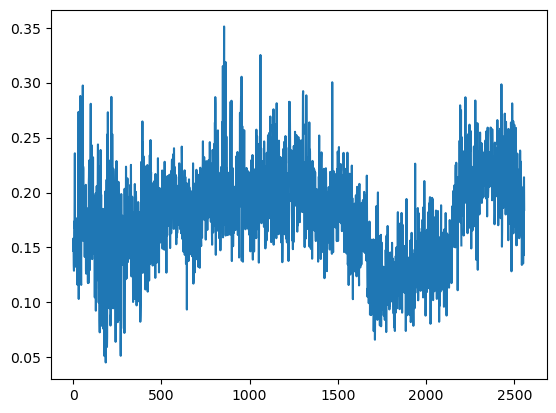

In [27]:
pd.DataFrame(tweets_classified_daily)["bearish_std"].plot()